170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 62ms/step - accuracy: 0.4936 - loss: 1.4244 - val_accuracy: 0.2610 - val_loss: 3.4010
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 61ms/step - accuracy: 0.6322 - loss: 1.0582 - val_accuracy: 0.6146 - val_loss: 1.0976
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 60ms/step - accuracy: 0.6887 - loss: 0.8975 - val_accuracy: 0.6501 - val_loss: 1.0132
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 62ms/step - accuracy: 0.7268 - loss: 0.7833 - val_accuracy: 0.6629 - val_loss: 1.0005
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 62ms/step - accuracy: 0.7578 - loss: 0.6950 - val_accuracy: 0.7036 - val_loss: 0.8946
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 62ms/step - accuracy: 0.7827 - loss: 0.6195 - val_accuracy: 0.6333 - val_loss: 1.1774
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 145s 64ms/step - accuracy: 0.8079 - loss: 0.5481 - val_accuracy: 0.7194 - val_loss: 0.8915
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 98s 63ms/step - accuracy: 0.8

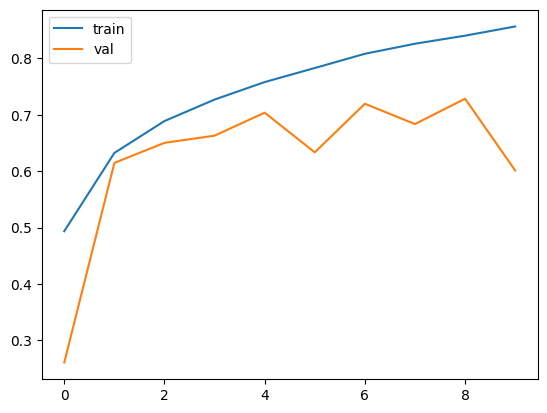

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6012 - loss: 1.4286
Accuracy: 0.6011999845504761


In [1]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt

(x_train,y_train),(x_test,y_test)=datasets.cifar10.load_data()

x_train=x_train/255.0
x_test=x_test/255.0

model=models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128,(3,3),activation='relu'))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(10,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history=model.fit(
    x_train,y_train,
    epochs=10,
    validation_data=(x_test,y_test)
)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.show()

test_loss,test_acc=model.evaluate(x_test,y_test)
print("Accuracy:",test_acc)